## Imports and paths

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [6]:
PROJECT_DIR = Path.cwd()
UNIFORM_DIR = PROJECT_DIR / "Cleaned Data" / "Uniform column format"
UNENCODED_INPUT_DIR = PROJECT_DIR / "Cleaned Data" / "002 Data Clean" / "cleaned_unencoded"

COUNTRIES = {"AUS": "Australia","BRA": "Brazil","CAN": "Canada","GBR": "United Kingdom","IND": "India","USA": "United States"}      # 6Countries

## 1 After Data Cleaning

,Country,Initial Rows,Retained Rows,Rows Removed,Retained Percentage,Unencoded Columns
0,Australia,53833,41745,12088,77.545372,27
1,Brazil,10308,10118,190,98.156771,39
2,Canada,48372,39911,8461,82.508476,26
3,United Kingdom,64532,32418,32114,50.235542,35
4,India,16145,15365,780,95.168783,37
5,United States,33940,17215,16725,50.721862,28


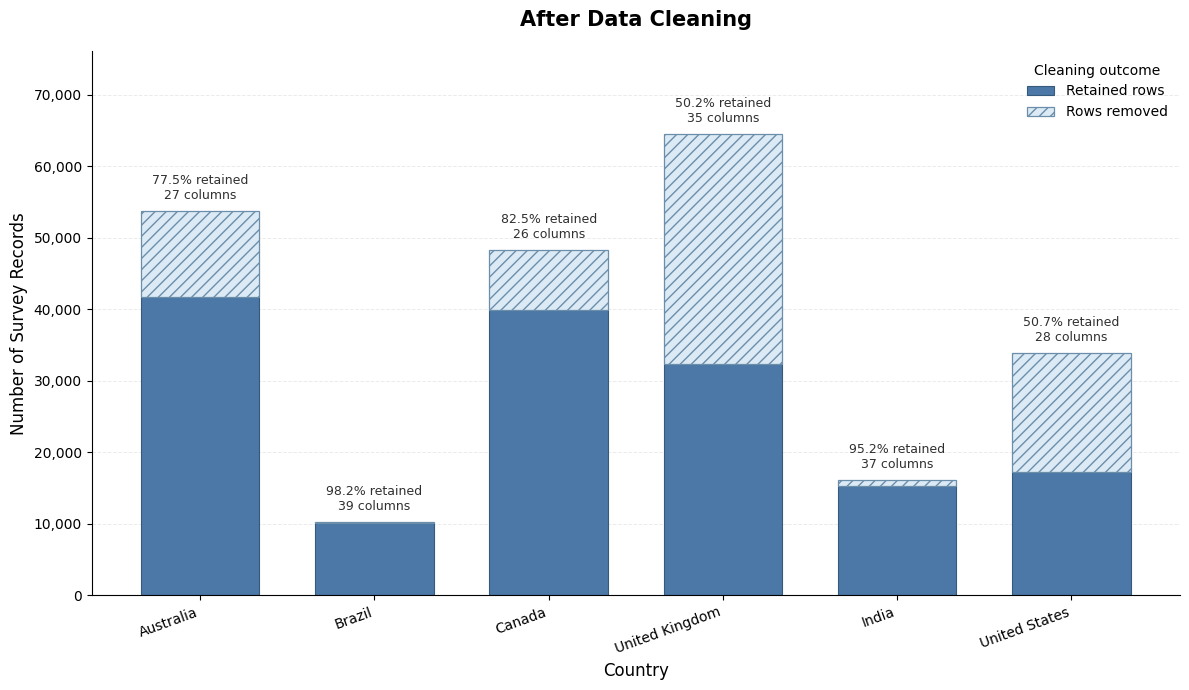

In [7]:
cleaned_data = {}
cleaning_rows = []

for code, country_name in COUNTRIES.items():
    safe_country_name = country_name.replace(" ", "_")

    uniform_path = UNIFORM_DIR / f"YouGov_{country_name}.csv"
    cleaned_path = UNENCODED_INPUT_DIR / f"YouGov_{safe_country_name}_cleaned_unencoded.csv"

    initial_rows = pd.read_csv(uniform_path,encoding="utf-8-sig",usecols=[0],low_memory=False).shape[0]             # Rows before Data Clean
    cleaned_df = pd.read_csv(cleaned_path,encoding="utf-8-sig",low_memory=False)                                    # Results saved by Data Clean
    retained_rows = cleaned_df.shape[0]

    cleaned_data[code] = cleaned_df
    cleaning_rows.append({
        "Country": country_name,
        "Initial Rows": initial_rows,
        "Retained Rows": retained_rows,
        "Rows Removed": initial_rows - retained_rows,
        "Retained Percentage": retained_rows / initial_rows * 100,
        "Unencoded Columns": cleaned_df.shape[1]})

cleaning_summary = pd.DataFrame(cleaning_rows)
display(cleaning_summary)


# X-axis positions
x = np.arange(len(cleaning_summary))
bar_width = 0.68

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

ax.bar(x,cleaning_summary["Retained Rows"],width=bar_width,color="#4C78A8",edgecolor="#355A7A",linewidth=0.8,label="Retained rows")
ax.bar(x,cleaning_summary["Rows Removed"],width=bar_width,bottom=cleaning_summary["Retained Rows"],color="#DCEAF5",edgecolor="#6B8EAA",linewidth=0.9,hatch="///",label="Rows removed")

# Add labels above each bar
for i, row in cleaning_summary.iterrows():
    ax.text(i,row["Initial Rows"] + 1200,f'{row["Retained Percentage"]:.1f}% retained\n{int(row["Unencoded Columns"])} columns',ha="center",va="bottom",fontsize=9,color="#303030")

# Format axes
ax.set_title("After Data Cleaning",fontsize=15,fontweight="semibold",pad=18)
ax.set_xlabel("Country",fontsize=12)
ax.set_ylabel("Number of Survey Records",fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(cleaning_summary["Country"],rotation=20,ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, position: f"{int(value):,}"))
ax.legend(title="Cleaning outcome",frameon=False)
ax.set_ylim(0,cleaning_summary["Initial Rows"].max() * 1.18)
ax.grid(axis="y",linestyle="--",linewidth=0.7,alpha=0.25)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 2 Before and After Mask-Mandate

,Country,Before Mandate,After Mandate,Total,After Mandate Percentage
0,Australia,15757,25988,41745,62.254162
1,Brazil,1479,8639,10118,85.382487
2,Canada,15856,24055,39911,60.271604
3,United Kingdom,1689,30729,32418,94.789932
4,India,1736,13629,15365,88.701595
5,United States,1796,15419,17215,89.567238


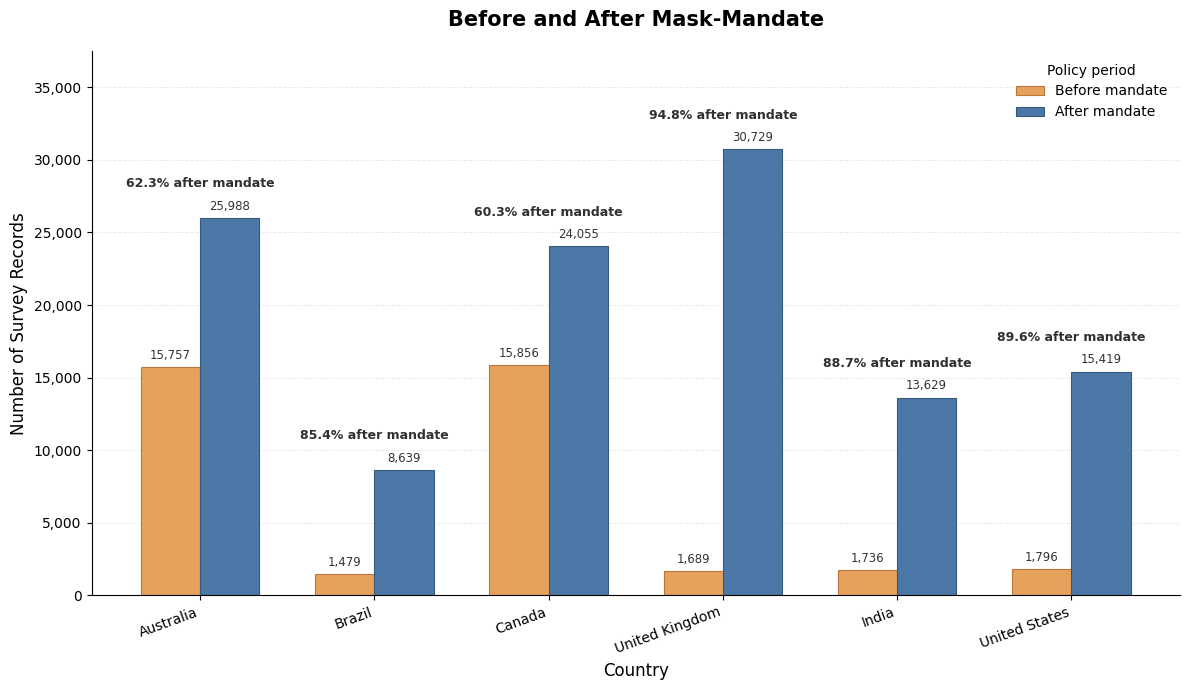

In [8]:
mandate_rows = []

for code, country_name in COUNTRIES.items():
    df = cleaned_data[code]

    mandate_rows.append({
        "Country": country_name,
        "Before Mandate": int((df["within_mandate_period"] == 0).sum()),
        "After Mandate": int((df["within_mandate_period"] == 1).sum()),
        "Total": df.shape[0]})

mandate_summary = pd.DataFrame(mandate_rows)
mandate_summary["After Mandate Percentage"] = mandate_summary["After Mandate"] / mandate_summary["Total"] * 100
display(mandate_summary)


# X-axis positions
x = np.arange(len(mandate_summary))
bar_width = 0.34

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

before_bars = ax.bar(x - bar_width / 2,mandate_summary["Before Mandate"],width=bar_width,color="#E6A15C",edgecolor="#B97838",linewidth=0.8,label="Before mandate")
after_bars = ax.bar(x + bar_width / 2,mandate_summary["After Mandate"],width=bar_width,color="#4C78A8",edgecolor="#355A7A",linewidth=0.8,label="After mandate")

# Values
for bars in [before_bars, after_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,height + 350,f"{int(height):,}",ha="center",va="bottom",fontsize=8.5,color="#333333")

# Percentage label
for i, row in mandate_summary.iterrows():
    group_height = max(row["Before Mandate"],row["After Mandate"])
    ax.text(i,group_height + 1900,f'{row["After Mandate Percentage"]:.1f}% after mandate',ha="center",va="bottom",fontsize=9,fontweight="semibold",color="#303030")

# Format axes
ax.set_title("Before and After Mask-Mandate",fontsize=15,fontweight="semibold",pad=18)
ax.set_xlabel("Country",fontsize=12)
ax.set_ylabel("Number of Survey Records",fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(mandate_summary["Country"],rotation=20,ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, position: f"{int(value):,}"))
ax.legend(title="Policy period",frameon=False)
ax.set_ylim(0,max(mandate_summary["Before Mandate"].max(),mandate_summary["After Mandate"].max()) * 1.22)
ax.grid(axis="y",linestyle="--",linewidth=0.7,alpha=0.25)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()